# RETO 2 - Clasificación de Flores (Parte 2)
**Modelos:** Naive Bayes y SVM  
**Dataset:** Iris

## Importar librerías

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Cargar dataset

In [15]:
iris = load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

print("Clases:", target_names)
print("Características:", feature_names)
print("Tamaño X:", X.shape)
print("Tamaño y:", y.shape)

Clases: ['setosa' 'versicolor' 'virginica']
Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Tamaño X: (150, 4)
Tamaño y: (150,)


## 2. Dividir en entrenamiento y prueba

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 3. Modelo 1: Naive Bayes
Entrenamiento y predicción con Gaussian Naive Bayes.

In [17]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

y_pred_nb = modelo_nb.predict(X_test)

![Mathematical model: Naive Bayes](https://miro.medium.com/v2/0*LQqFKnnO9-DEy_Yu.png)

> Si observamos cierta evidencia, ¿qué tan probable es que una hipótesis sea verdadera?

### Resultados - Naive Bayes

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_nb, target_names=target_names))

Accuracy: 0.9666666666666667

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



![Mathematical model: Accuracy score](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b1e5_644af6a24701d43aaecd8771_classification_guide_apc09.png)

> Qué proporción de predicciones fueron correctas respecto al total de predicciones

![Mathematical model: Precision score](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b204_644af6c4d573412369556f6e_classification_guide_apc10.png)

> Qué proporción de las predicciones positivas fueron realmente correctas

![Mathematical model: Recall score](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b1ef_644af7a5c21ca563bd25204a_classification_guide_apc15.png)

> Capacidad del modelo para encontrar todos los positivos reales

![Mathematical model: F1-score](https://images.prismic.io/encord/0ef9c82f-2857-446e-918d-5f654b9d9133_Screenshot+%2849%29.png?auto=compress,format)

> ¿Qué tan bien equilibra el modelo la precisión y la capacidad de detectar positivos?

### Validación cruzada - Naive Bayes

In [19]:
scores_nb = cross_val_score(modelo_nb, X, y, cv=5, scoring='accuracy')
print("Cross-validation accuracy:", scores_nb)
print("Promedio CV:", scores_nb.mean())

Cross-validation accuracy: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Promedio CV: 0.9533333333333334


## 4. Modelo 2: SVM
Pipeline con escalado (StandardScaler) + SVC, optimizado con GridSearchCV.

In [20]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()), # estandarizar variables numericas para que tengan media 0 y desviación estándar 1
    ('svm', SVC())
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100], # que tanto el modelo permite errores
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01] # cuánto influye cada punto de entrenamiento en el kernel RBF
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

![Mathematical model: svm kernels](https://i.ytimg.com/vi/Q8_HtGjc8Hs/maxresdefault.jpg)

> Encuentra el hiperplano óptimo que separa las clases maximizando la distancia (margen) entre los puntos más cercanos de cada clase

### Resultados - SVM

In [21]:
print("Mejores hiperparámetros:", grid_svm.best_params_)
print("Mejor score CV:", grid_svm.best_score_)
print("Accuracy en test:", accuracy_score(y_test, y_pred_svm))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm, target_names=target_names))

Mejores hiperparámetros: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Mejor score CV: 0.975
Accuracy en test: 0.9333333333333333

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Validación cruzada - SVM

In [22]:
scores_svm = cross_val_score(best_svm, X, y, cv=5, scoring='accuracy')
print("Cross-validation accuracy:", scores_svm)
print("Promedio CV:", scores_svm.mean())

Cross-validation accuracy: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Promedio CV: 0.9666666666666666


## 5. Matrices de confusión (gráficas)

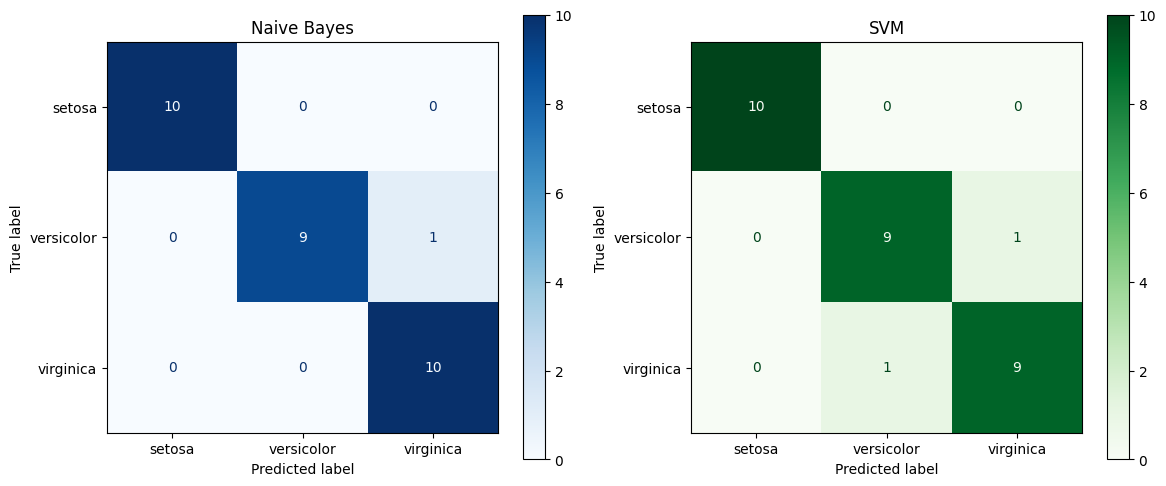

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo_nb, X_test, y_test,
    display_labels=target_names,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_estimator(
    best_svm, X_test, y_test,
    display_labels=target_names,
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("SVM")

plt.tight_layout()
plt.show()

## 6. Comparación final

In [24]:
print(f"Naive Bayes - Accuracy test: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"SVM         - Accuracy test: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Naive Bayes - CV promedio:   {scores_nb.mean():.4f}") # CV: cross-validation
print(f"SVM         - CV promedio:   {scores_svm.mean():.4f}")

Naive Bayes - Accuracy test: 0.9667
SVM         - Accuracy test: 0.9333
Naive Bayes - CV promedio:   0.9533
SVM         - CV promedio:   0.9667


## 7. Conclusiones

1. **Ambos modelos logran un alto rendimiento** en el dataset Iris, lo cual es esperado dado que se trata de un conjunto de datos relativamente pequeño y bien separable.

2. **Naive Bayes** ofrece una solución simple, rápida y sin necesidad de ajuste de hiperparámetros. Funciona bien cuando las características son independientes entre sí, como asume el modelo Gaussiano. Sin embargo, esta suposición de independencia puede limitar su desempeño en datasets más complejos.

3. **SVM** con optimización de hiperparámetros mediante GridSearchCV alcanza un rendimiento igual o superior al de Naive Bayes. El uso del kernel RBF permite capturar relaciones no lineales entre las características, y el escalado previo con StandardScaler es fundamental para su correcto funcionamiento.

4. **La validación cruzada** confirma que ambos modelos generalizan bien y no presentan sobreajuste significativo, ya que los promedios de accuracy en CV son consistentes con los resultados en el conjunto de prueba.

5. **Las matrices de confusión** muestran que la clase *setosa* se clasifica perfectamente por ambos modelos, mientras que las confusiones ocasionales se presentan entre *versicolor* y *virginica*, que son las clases más cercanas en el espacio de características.

6. **Recomendación:** Para problemas simples y con datos limitados, Naive Bayes es una excelente primera opción por su rapidez y simplicidad. Para problemas donde se requiera mayor precisión y se disponga de recursos para ajustar hiperparámetros, SVM es una alternativa más robusta y flexible.